# Counterfactual Explanations Tutorial - Artelt & Hammer Method

Welcome to this tutorial on **Artelt & Hammer (2020)** approach to generating counterfactual explanations with convex density constraints!

## What are Plausible Counterfactual Explanations?

While traditional counterfactual explanations answer: *"What would need to change for a different prediction?"*, **plausible counterfactuals** go one step further by ensuring the generated explanations are realistic and feasible.

The key insight of Artelt & Hammer is that counterfactuals should not only change the prediction but also lie within **high-density regions** of the data distribution, making them more plausible and actionable.


# Import necessary libraries

We'll need additional libraries for density estimation and optimization compared to the Wachter method.


In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = "cpu"

## The Artelt & Hammer (2020) Formulation

The paper [*Convex Density Constraints for Computing Plausible Counterfactual Explanations*](https://arxiv.org/pdf/2002.04862) introduces a novel approach that ensures counterfactuals are both **close to the original instance** and **plausible** by lying in high-density regions.

### Key Innovation

Traditional methods like Wachter *et al.* only consider:
- **Proximity**: Minimize distance to original instance  
- **Prediction change**: Achieve desired target prediction  

Artelt & Hammer add a third crucial component:
- **Plausibility**: Ensure counterfactual lies in high-density regions of the data distribution  

### The Optimization Problem

The authors formulate this as a constrained optimization problem:

$$
\begin{aligned}
\min_{x'} \quad & \|x' - x\|_2^2 \\
\text{s.t.} \quad & f(x') = y', \\
& p(x') \ge \tau
\end{aligned}
$$

Where:
- $x'$: Counterfactual instance  
- $x$ Original instance  
- $f(x')$: Model prediction  
- $y'$: Target prediction  
- $p(x')$: Data density at $x'$  
- $\tau$: Density threshold (minimum plausibility level)


## Reformulation as Unconstrained Optimization

To solve this optimization problem using gradient-based methods, we reformulate the constrained problem as an **unconstrained optimization** problem:

### The Loss Function

$$L(x') = \lambda_1 \cdot d(x, x') + \lambda_2 \cdot \ell(f(x'), y') + \lambda_3 \cdot \phi(p(x'))$$

Where:
- **$d(x, x')$**: Distance function (typically L2 distance: $||x' - x||_2^2$)  
- **$\ell(f(x'), y')$**: Loss function measuring how far $f(x')$ is from the target $y'$  
- **$\phi(p(x'))$**: Density penalty function (encourages high-density regions)  
- **$\lambda_1, \lambda_2, \lambda_3$**: Hyperparameters balancing proximity, prediction change, and plausibility  

### Distance Component

Same as Wachter method - encourages proximity:

$$d(x, x') = ||x' - x||_2^2 = \sum_{i=1}^{d} (x'_i - x_i)^2$$

### Prediction Loss Component

Same as Wachter method - encourages correct prediction:

$$\ell(f(x'), y') = \max(0, \tau - (f(x') - 0.5) \cdot (2y' - 1))$$

### Density Penalty Component

The key novelty - encourages plausibility:

$$\phi(p(x')) = -\log(p(x'))$$

This penalty is:
- **Low** when p(x') is high (plausible regions)
- **High** when p(x') is low (implausible regions)

### Density Estimation

To compute p(x'), we need to estimate the data density. Common approaches:

1. **Gaussian Mixture Model (GMM)**: Models data as mixture of Gaussians
2. **Kernel Density Estimation (KDE)**: Non-parametric density estimation
3. **Normalizing Flows**: Deep learning-based density estimation

For this tutorial, we'll use **GMM** as it's efficient and works well for the moons dataset.

### Gradient-Based Optimization

The optimization becomes:

$$x'^{(t+1)} = x'^{(t)} - \alpha \nabla_{x'} L(x'^{(t)})$$

Where the gradient includes the density term:

$$\nabla_{x'} L(x') = \lambda_1 \nabla_{x'} d(x, x') + \lambda_2 \nabla_{x'} \ell(f(x'), y') + \lambda_3 \nabla_{x'} \phi(p(x'))$$

The density gradient requires computing:

$$\nabla_{x'} \phi(p(x')) = -\frac{\nabla_{x'} p(x')}{p(x')}$$

This can be computed using automatic differentiation if p(x') is differentiable (e.g., GMM).


## Dataset: Two Moons

We'll use the same "two moons" dataset for consistency with the Wachter tutorial. This dataset is perfect for demonstrating density constraints because:

1. **Clear density patterns**: Each moon forms a high-density region
2. **Low-density gaps**: Space between moons has low density
3. **Visual interpretability**: Easy to see when counterfactuals are plausible vs. implausible


In [2]:
from counterfactuals.datasets.file_dataset import FileDataset
from counterfactuals.datasets.preprocess_datasets.preprocess_moons import (
    transform_moons,
)


dataset = FileDataset(config_path="../config/datasets/moons.yaml")
dataset.X_train, dataset.X_test, dataset.y_train, dataset.y_test = transform_moons(
    dataset.X_train, dataset.X_test, dataset.y_train, dataset.y_test
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(dataset.X_train)
X_test_scaled = scaler.transform(dataset.X_test)

dataset.X_train, dataset.X_test = X_train_scaled, X_test_scaled

train_dataset = TensorDataset(
    torch.tensor(dataset.X_train, dtype=torch.float32),
    torch.tensor(dataset.y_train, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(dataset.X_test, dtype=torch.float32),
    torch.tensor(dataset.y_test, dtype=torch.float32),
)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

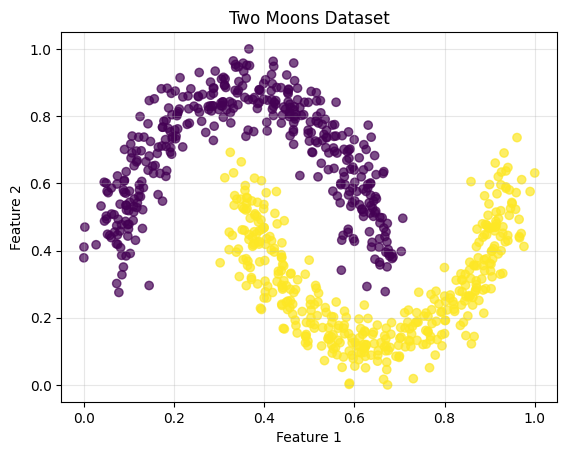

In [3]:
# Visualize the dataset
plt.figure()
scatter = plt.scatter(
    dataset.X_train[:, 0],
    dataset.X_train[:, 1],
    c=dataset.y_train,
    cmap="viridis",
    alpha=0.7,
)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

## Neural Network Model

We'll use the same neural network architecture as in the Wachter tutorial for consistency.


In [4]:
from counterfactuals.models.classifier.multilayer_perceptron import MLPClassifier


discriminative_model = MLPClassifier(2, 2, [128, 128, 128], dropout=0.0)

## Model Training


In [5]:
discriminative_model.fit(
    train_dataloader, test_dataloader, epochs=10000, patience=1000, lr=0.001
)

Epoch 1094, Train: 0.0000, test: 0.0000, patience: 1000:  11%|█         | 1095/10000 [00:24<03:16, 45.35it/s]


/Users/lukasz/Desktop/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


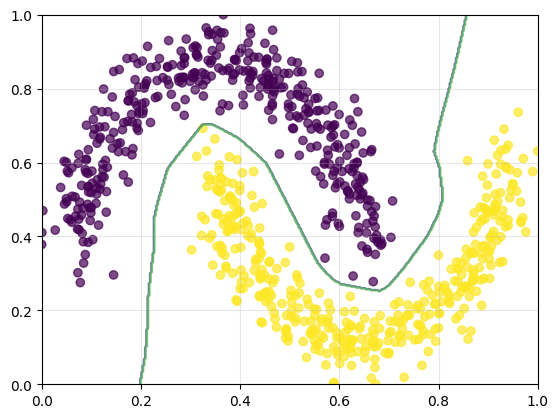

In [6]:
from counterfactuals.plotting.plot_utils import plot_classifier_decision_region

fig, ax = plt.subplots(1, 1)
ax.scatter(
    dataset.X_train[:, 0],
    dataset.X_train[:, 1],
    c=dataset.y_train,
    cmap="viridis",
    alpha=0.7,
)
ax.grid(True, alpha=0.3)
plot_classifier_decision_region(ax, discriminative_model)
plt.show()

## Density Estimation

Now we need to estimate the data density to implement the plausibility constraint. We'll use a Gaussian Mixture Model (GMM) to model the data distribution.


In [7]:
# Fit Gaussian Mixture Model for density estimation
generative_model = GaussianMixture(n_components=4, random_state=42)
X_train_scaled_1 = X_train_scaled[dataset.y_train == 1]
generative_model.fit(X_train_scaled_1)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [8]:
class GMMDensityModel(torch.nn.Module):
    """Simple nn.Module wrapper providing a log-prob interface like MaskedAutoregressiveFlow."""

    def __init__(self, gmm):
        super().__init__()
        self.gmm = gmm

    def forward(self, x, context=None):
        if not isinstance(x, torch.Tensor):
            raise TypeError("x must be a torch.Tensor")
        if x.dim() == 1:
            x = x.unsqueeze(0)
        x_cpu = x.detach().cpu()
        log_prob = self.gmm.score_samples(x_cpu.numpy())
        return torch.from_numpy(log_prob).to(x.device).to(x.dtype)


generative_model = GMMDensityModel(generative_model)

---

# 🚀 **YOUR TURN: Implement Plausible Counterfactual Generation**

Now it's time for you to implement the Artelt & Hammer counterfactual generation algorithm!

## Task Overview

Your goal is to implement a `PlausibleCounterfactualGenerator` class that:

1. **Takes an input instance** and finds the closest plausible counterfactual explanation
2. **Uses gradient-based optimization** to minimize the loss function: `L(x') = λ₁ * d(x, x') + λ₂ * ℓ(f(x'), y') + λ₃ * φ(p(x'))`
3. **Ensures plausibility** by incorporating density constraints
4. **Returns the counterfactual instance** that changes the model's prediction while staying in high-density regions

## Implementation Guidelines

### Class Structure
```python
class PlausibleCounterfactualGenerator:
    def __init__(self):
        # Initialize your plausible counterfactual generator
        pass
    
    def generate(self):
        # Generate plausible counterfactual explanation for x_orig
        # Returns: counterfactual instance, success flag, iterations used
        pass
```

### Key Components to Implement

1. **Distance Function**: Implement L2 distance `d(x, x')`
2. **Prediction Loss**: Choose between margin loss or cross-entropy loss
3. **Density Penalty**: Implement `φ(p(x')) = -log(p(x'))`
4. **Gradient Optimization**: Use PyTorch's autograd for gradient computation
5. **Stopping Criteria**: Stop when target prediction is achieved or max iterations reached

### Hints

- Initialize `x'` as a copy of the original input `x`
- Make `x'` a PyTorch tensor with `requires_grad=True`
- Use `torch.optim.Adam` or `torch.optim.SGD` for optimization
- For density computation, you'll need to convert PyTorch tensors to numpy for GMM
- Consider using `torch.autograd.Function` for custom density gradient computation
- Track all three loss components separately for debugging

### Density Gradient Computation

The tricky part is computing gradients through the GMM density function. You have several options:

1. **Finite differences**: Approximate gradients numerically
2. **Custom autograd function**: Implement the GMM gradient manually
3. **PyTorch GMM**: Use a PyTorch implementation of GMM (if available)

For simplicity, you can start with finite differences and then optimize if needed.

## Your Implementation Space

👇 **Write your code in the cells below** 👇


In [9]:
import torch
import torch.nn.functional as F
from torch.distributions import Categorical, MixtureSameFamily, MultivariateNormal


class PlausibleCounterfactualGenerator:
    def __init__(
        self,
        model,
        gmm,
        lambda1=1.0,
        lambda2=1.0,
        lambda3=1.0,
        lr=0.01,
        max_iterations=1000,
    ):
        """Initialize the plausible counterfactual generator."""
        self.model = model
        self.gmm = gmm
        self.lambda1 = float(lambda1)
        self.lambda2 = float(lambda2)
        self.lambda3 = float(lambda3)
        self.lr = float(lr)
        self.max_iterations = int(max_iterations)

        for p in self.model.parameters():
            p.requires_grad_(False)
        self.model.eval()

        self._weights = torch.from_numpy(self.gmm.gmm.weights_.astype("float32"))
        self._means = torch.from_numpy(self.gmm.gmm.means_.astype("float32"))
        self._covariances = torch.from_numpy(
            self.gmm.gmm.covariances_.astype("float32")
        )
        self._covariance_type = self.gmm.gmm.covariance_type
        self._feature_dim = self._means.shape[1]

    def distance_loss(self, x_orig, x_cf):
        return ((x_cf - x_orig) ** 2).mean()

    def _model_target_prob(self, logits, target_class):
        if logits.dim() == 1:
            logits = logits.unsqueeze(0)
        if logits.shape[-1] == 1:
            p1 = torch.sigmoid(logits.squeeze(-1))
            if target_class == 1:
                return p1
            return 1.0 - p1
        probs = F.softmax(logits, dim=-1)
        return probs[:, int(target_class)]

    def prediction_loss(self, x_cf, target_class):
        logits = self.model(x_cf)
        y = torch.full(
            (logits.shape[0],),
            int(target_class),
            device=logits.device,
            dtype=torch.long,
        )
        loss = F.cross_entropy(logits, y)
        return loss

    def _build_mixture_distribution(self, device, dtype):
        weights = self._weights.to(device=device, dtype=dtype)
        means = self._means.to(device=device, dtype=dtype)
        covs_raw = self._covariances.to(device=device, dtype=dtype)
        jitter = 1e-6 * torch.eye(self._feature_dim, device=device, dtype=dtype)
        covs_raw = covs_raw + jitter.unsqueeze(0)
        return MixtureSameFamily(
            Categorical(probs=weights),
            MultivariateNormal(loc=means, covariance_matrix=covs_raw),
        )

    def density_penalty(self, x_cf):
        x_flat = x_cf.view(x_cf.size(0), -1)
        dist = self._build_mixture_distribution(x_flat.device, x_flat.dtype)
        log_prob = dist.log_prob(x_flat)
        return -log_prob.mean()

    def generate(self, x_orig, target_class, tolerance=0.1):
        device = (
            next(self.model.parameters()).device
            if any(True for _ in self.model.parameters())
            else x_orig.device
        )
        x_cf = x_orig.clone().detach().requires_grad_(True)
        optimizer = torch.optim.Adam([x_cf], lr=self.lr)

        loss_history = []

        for it in range(1, self.max_iterations + 1):
            optimizer.zero_grad(set_to_none=True)
            d_loss = self.distance_loss(x_orig, x_cf)
            p_loss = self.prediction_loss(x_cf, target_class)
            dens_penalty = self.density_penalty(x_cf)
            loss = (
                self.lambda1 * d_loss
                + self.lambda2 * p_loss
                + self.lambda3 * dens_penalty
            )
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                logits = self.model(x_cf)
                p_target = self._model_target_prob(logits, target_class)
            loss_history.append(
                {
                    "total": float(loss.item()),
                    "distance": float(d_loss.item()),
                    "prediction": float(p_loss.item()),
                    "density": float(dens_penalty.item()),
                    "target_prob": float(p_target.mean().item()),
                }
            )

        x_cf_out = x_cf.detach()
        if x_orig.dim() == 1 and x_cf_out.dim() > 1:
            x_cf_out = x_cf_out.squeeze(0)

        return x_cf_out

In [10]:
cf_generator = PlausibleCounterfactualGenerator(
    discriminative_model, generative_model, lambda3=1
)
X_test_orig = dataset.X_test[dataset.y_test == 0]
y_test_origin = dataset.y_test[dataset.y_test == 0]
X_test_orig = torch.tensor(X_test_orig)
X_test_cfs = cf_generator.generate(X_test_orig, 1)

# Expected plot

![artelt_vis](../assets/artelt_example.png)

/Users/lukasz/Desktop/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/counterfactuals/plotting/counterfactual_visualization.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lukasz/Desktop/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/counterfactuals/plotting/counterfactual_visualization.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


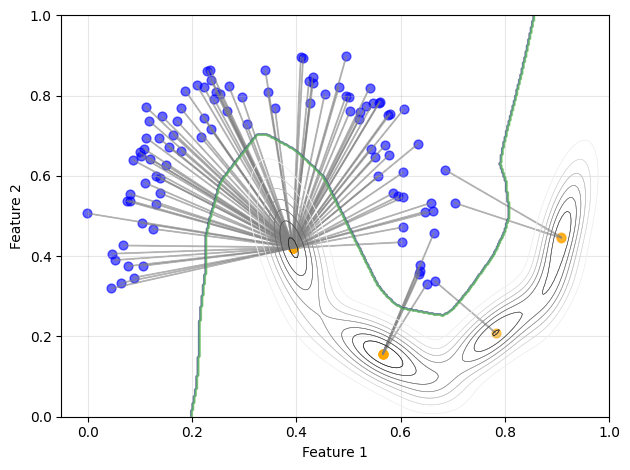

In [11]:
from counterfactuals.plotting.counterfactual_visualization import plot_counterfactuals

plot_counterfactuals(
    X_test_orig, X_test_cfs, 10, discriminative_model, gen_model=generative_model
)

In [12]:
from counterfactuals.metrics.orchestrator import MetricsOrchestrator

y_target = np.abs(1 - y_test_origin)


metrics_cf = MetricsOrchestrator(
    disc_model=discriminative_model,
    gen_model=generative_model,
    X_cf=X_test_cfs,
    X_train=dataset.X_train,
    y_train=dataset.y_train,
    X_test=X_test_orig,
    y_test=y_test_origin,
    y_target=y_target,
    continuous_features=[0, 1],
    categorical_features=[],
    ratio_cont=None,
    prob_plausibility_threshold=np.median(
        generative_model.gmm.score_samples(X_train_scaled_1)
    ),
    metrics_conf_path="../config/metrics/plausibility.yaml",
)
metrics = metrics_cf.calculate_all_metrics()

In [13]:
metrics

{'coverage': 1.0,
 'validity': 1.0,
 'actionability': 0.0,
 'sparsity': 1.0,
 'proximity_categorical_hamming': 0.3466871447631933,
 'proximity_categorical_jaccard': 0.3466871447631933,
 'proximity_continuous_manhattan': 0.44487997429149057,
 'proximity_continuous_euclidean': 0.3466871447631933,
 'proximity_continuous_mad': 2.349914610987962,
 'proximity_l2_jaccard': 0.3466871447631933,
 'proximity_mad_hamming': 2.349914610987962,
 'prob_plausibility': 1.0,
 'log_density_cf': 2.3805432319641113,
 'log_density_test': -16.823657989501953,
 'lof_scores_cf': 0.9680676460266113,
 'lof_scores_test': 1.0636862516403198,
 'isolation_forest_scores_cf': 0.033651791873745895,
 'isolation_forest_scores_test': 0.00497389017100576}

### Plausibility Metrics:

- **Isolation Forest Score**: anomaly / outlier score from isolation forest — lower is “more normal” → more plausible
- **LOF Score**: local outlier factor — if near 1, counterfactual is locally consistent with data; high values flag implausibility
- **Probabilistic Plausibility** (Density Constraint): the estimated conditional density (under target class) at the counterfactual must exceed a threshold $\delta$; ensures counterfactual lies in dense, realistic regions

## Summary

In this tutorial, you've learned about the **Artelt & Hammer (2020)** approach to generating plausible counterfactual explanations:

### Key Concepts

1. **Plausibility Constraint**: Counterfactuals should lie in high-density regions of the data distribution
2. **Three-Component Loss**: Distance + Prediction + Density penalty
3. **Density Estimation**: Using GMM to model data distribution
4. **Gradient Optimization**: Minimizing the combined loss function

### Advantages over Wachter Method

- **More realistic**: Counterfactuals are more likely to occur in practice
- **Better interpretability**: Users can trust that changes are feasible
- **Robust**: Less likely to generate out-of-distribution examples

### Challenges

- **Computational complexity**: Requires density estimation and gradient computation
- **Hyperparameter tuning**: Need to balance three loss components
- **Density estimation quality**: Results depend on the quality of density model

### Next Steps

Consider exploring:
- Different density estimation methods (KDE, Normalizing Flows)
- Adaptive hyperparameter selection
- Comparison with other plausibility constraints
- Application to higher-dimensional datasets
